In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ranasabrii/chinook/Chinook_Sqlite.sqlite


## Connect to the Database 
First, establish the connection and explore what tables are available.

In [2]:
import sqlite3
# Connect to the database file
conn = sqlite3.connect('/kaggle/input/datasets/ranasabrii/chinook/Chinook_Sqlite.sqlite')

###  understand the schema

In [3]:
# Get a list of all tables to understand the schema
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)
print(tables)

             name
0           Album
1          Artist
2        Customer
3        Employee
4           Genre
5         Invoice
6     InvoiceLine
7       MediaType
8        Playlist
9   PlaylistTrack
10          Track


## Answering Business Questions
### A. Top-Selling Products (Most Popular Tracks)
To find the top sellers, we need to JOIN the Track table with the InvoiceLine table.

In [4]:
query_top_products = """
SELECT 
    t.Name AS TrackName, 
    COUNT(il.InvoiceLineId) AS TotalSales
FROM Track t
JOIN InvoiceLine il ON t.TrackId = il.TrackId
GROUP BY t.TrackId
ORDER BY TotalSales DESC
LIMIT 10;
"""


In [5]:
top_products = pd.read_sql_query(query_top_products, conn)
print(top_products)

                   TrackName  TotalSales
0          Balls to the Wall           2
1           Inject The Venom           2
2                 Snowballed           2
3                   Overdose           2
4            Deuces Are Wild           2
5             Not The Doctor           2
6          Por Causa De Você           2
7  Welcome Home (Sanitarium)           2
8                  Snowblind           2
9                 Cornucopia           2


### B. Monthly Performance (Revenue over Time)
We use the Invoice table and the strftime function (SQLite's way of formatting dates) to group by month.

In [6]:
query_monthly = """
SELECT 
    strftime('%Y-%m', InvoiceDate) AS Month,
    SUM(Total) AS MonthlyRevenue
FROM Invoice
GROUP BY Month
ORDER BY Month ASC;
"""


In [7]:
monthly_sales = pd.read_sql_query(query_monthly, conn)
monthly_sales

,Month,MonthlyRevenue
0,2009-01,35.64
1,2009-02,37.62
2,2009-03,37.62
3,2009-04,37.62
4,2009-05,37.62
5,2009-06,37.62
6,2009-07,37.62
7,2009-08,37.62
8,2009-09,37.62
9,2009-10,37.62


### Window Functions
To rank customers by how much they have spent, we use the RANK() window function. This is "pro" level because it calculates the rank without collapsing rows like a GROUP BY would.

In [8]:
query_rank = """
SELECT 
    CustomerId, 
    SUM(Total) as TotalSpent,
    RANK() OVER (ORDER BY SUM(Total) DESC) as CustomerRank
FROM Invoice
GROUP BY CustomerId
LIMIT 10;
"""


In [9]:
customer_ranks = pd.read_sql_query(query_rank, conn)
print(customer_ranks)

   CustomerId  TotalSpent  CustomerRank
0           6       49.62             1
1          26       47.62             2
2          57       46.62             3
3          45       45.62             4
4          46       45.62             4
5          28       43.62             6
6          24       43.62             7
7          37       43.62             7
8           7       42.62             9
9          25       42.62             9


## Top-Selling Products 
We join the Track and InvoiceLine tables to see which songs generated the most sales events.

In [10]:
query_top_tracks = """
SELECT t.Name, COUNT(il.InvoiceLineId) as SalesCount
FROM Track t
JOIN InvoiceLine il ON t.TrackId = il.TrackId
GROUP BY t.Name
ORDER BY SalesCount DESC
LIMIT 10;
"""
top_tracks = pd.read_sql_query(query_top_tracks, conn)



/tmp/ipykernel_17/503262154.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_tracks, x='SalesCount', y='Name', palette='viridis')


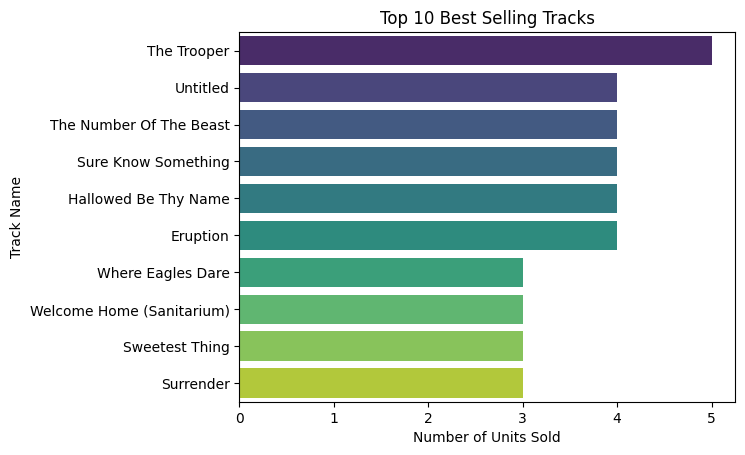

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
# Plotting
sns.barplot(data=top_tracks, x='SalesCount', y='Name', palette='viridis')
plt.title('Top 10 Best Selling Tracks')
plt.xlabel('Number of Units Sold')
plt.ylabel('Track Name')
plt.savefig('top_tracks.png')
plt.show()

## Revenue per Region
To identify the most profitable markets, we look at the Total column in the Invoice table, grouped by BillingCountry.

In [12]:
query_revenue_region = """
SELECT BillingCountry, SUM(Total) as TotalRevenue
FROM Invoice
GROUP BY BillingCountry
ORDER BY TotalRevenue DESC
LIMIT 10;
"""


In [13]:
revenue_region = pd.read_sql_query(query_revenue_region, conn)



/tmp/ipykernel_17/3589582060.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=revenue_region, x='TotalRevenue', y='BillingCountry', palette='magma')


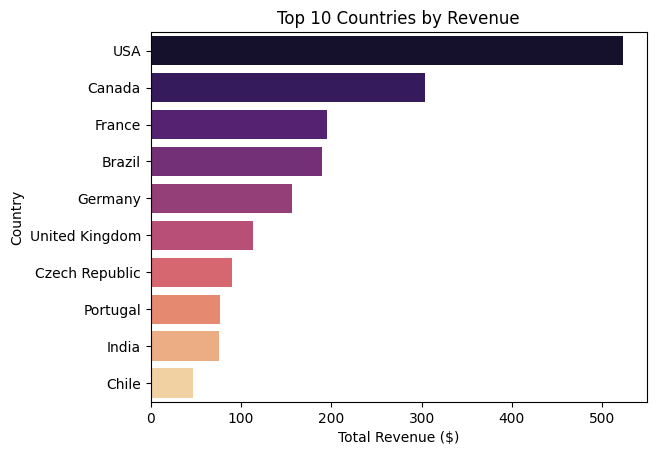

In [14]:
# Plotting
sns.barplot(data=revenue_region, x='TotalRevenue', y='BillingCountry', palette='magma')
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Total Revenue ($)')
plt.ylabel('Country')
plt.savefig('revenue_by_country.png')
plt.show()

## Monthly Performance (Line Chart)
This shows the business trend over time. We use strftime to truncate the date to the month level.

In [15]:
query_monthly = """
SELECT strftime('%Y-%m', InvoiceDate) as Month, SUM(Total) as Revenue
FROM Invoice
GROUP BY Month
ORDER BY Month ASC;
"""


In [16]:
monthly_perf = pd.read_sql_query(query_monthly, conn)



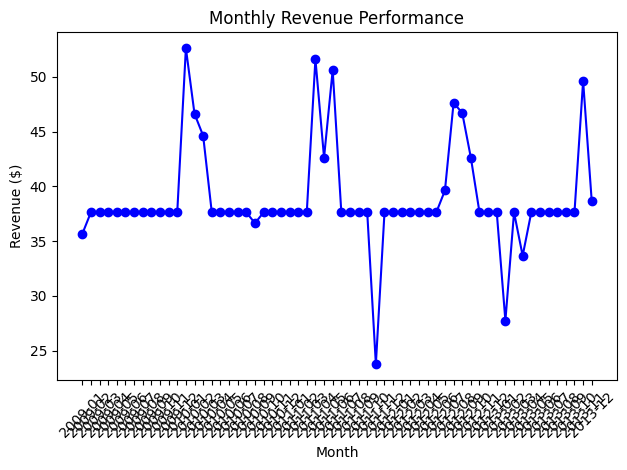

In [17]:
# Plotting
plt.plot(monthly_perf['Month'], monthly_perf['Revenue'], marker='o', linestyle='-', color='b')
plt.xticks(rotation=45)
plt.title('Monthly Revenue Performance')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.tight_layout()
plt.savefig('monthly_performance.png')
plt.show()

## Customer Spend vs. Rank 
If you want to see the "Pareto" effect (top customers providing the most revenue), we use a window function to rank them.

In [18]:
query_window = """
SELECT 
    CustomerId, 
    SUM(Total) as TotalSpent,
    RANK() OVER (ORDER BY SUM(Total) DESC) as CustomerRank
FROM Invoice
GROUP BY CustomerId
LIMIT 20;
"""


In [19]:
rank_df = pd.read_sql_query(query_window, conn)



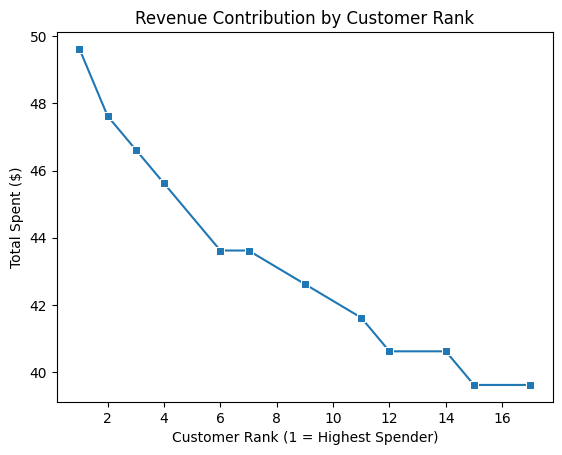

In [20]:
# Plotting
sns.lineplot(data=rank_df, x='CustomerRank', y='TotalSpent', marker='s')
plt.title('Revenue Contribution by Customer Rank')
plt.xlabel('Customer Rank (1 = Highest Spender)')
plt.ylabel('Total Spent ($)')
plt.savefig('customer_ranking.png')
plt.show()



In [21]:
# Close connection
conn.close()